# CrowdControl – Stampede Prediction

## 0. Setup – unzip dataset

In [15]:
import zipfile

with zipfile.ZipFile('img_zip.zip', 'r') as zip_ref:
    zip_ref.extractall('images')

In [16]:
#from google.colab import drive
#Tdrive.mount('/content/drive')

## 1. Imports & Configuration

In [17]:

# ─── Standard library ────────────────────────────────────────────────────────
import os
import numpy as np
import cv2
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tqdm import tqdm

# ─── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    matthews_corrcoef, fbeta_score
)

# ─── TensorFlow / Keras ───────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow version: {tf.__version__}")

# ─── Configuration ────────────────────────────────────────────────────────────
IMG_SIZE     = 100
BATCH_SIZE   = 32
EPOCHS_MCNN  = 30
KFOLD_SPLITS = 5
RANDOM_SEED  = 42
PATH_LABELS  = 'labels.csv'
PATH_IMAGES  = 'images/'
OUTPUT_DIR   = 'output_plots/'

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

TensorFlow version: 2.19.0


## 2. Load Dataset

In [18]:
print("=" * 60)
print("STEP 1: Loading Dataset")
print("=" * 60)

images_list, labels_list = [], []

with open(PATH_LABELS, 'r') as f:
    lines = f.readlines()[1:]   # skip header

for line in tqdm(lines, desc="Loading images"):
    line = line.strip()
    if not line:
        continue
    fname, label = line.split(',')
    img_path = os.path.join(PATH_IMAGES, fname)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"  [WARNING] Could not read {img_path}, skipping.")
        continue

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype('float32') / 255.0
    images_list.append(img)
    labels_list.append(int(label))

X = np.array(images_list)[..., np.newaxis]   # (N, H, W, 1)
y = np.array(labels_list, dtype='int32') #earlier it was float32

shuffle_idx = np.random.permutation(len(X))
X, y = X[shuffle_idx], y[shuffle_idx]
#np.random.shuffle(y)

print(f"\nDataset loaded:")
print(f"  Total images : {len(X)}")
print(f"  Stampede (1) : {int(y.sum())}")
print(f"  Safe     (0) : {int((1 - y).sum())}")
print(f"  Image shape  : {X.shape[1:]}")

STEP 1: Loading Dataset


Loading images:  45%|████▍     | 538/1199 [00:00<00:00, 5379.71it/s]

  [WARNING] Could not read images/97.jpg, skipping.
  [WARNING] Could not read images/98.jpg, skipping.
  [WARNING] Could not read images/99.jpg, skipping.
  [WARNING] Could not read images/970.jpg, skipping.
  [WARNING] Could not read images/971.jpg, skipping.
  [WARNING] Could not read images/972.jpg, skipping.
  [WARNING] Could not read images/973.jpg, skipping.
  [WARNING] Could not read images/994.jpg, skipping.
  [WARNING] Could not read images/995.jpg, skipping.
  [WARNING] Could not read images/996.jpg, skipping.
  [WARNING] Could not read images/997.jpg, skipping.
  [WARNING] Could not read images/998.jpg, skipping.
  [WARNING] Could not read images/999.jpg, skipping.


Loading images: 100%|██████████| 1199/1199 [00:00<00:00, 5113.55it/s]



Dataset loaded:
  Total images : 1186
  Stampede (1) : 588
  Safe     (0) : 598
  Image shape  : (100, 100, 1)


## 3. Data Augmentation

In [19]:
print("=" * 60)
print("STEP 2: Data Augmentation")
print("=" * 60)

train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=5,
    zoom_range=0.05,
    brightness_range=[0.85, 1.15],
    width_shift_range=0.05,
    height_shift_range=0.05,
)

val_datagen = ImageDataGenerator()   # no augmentation for validation

print("  Augmentation configured (gentle – crowd-image safe):")
print("   • Horizontal flip")
print("   • Rotation ±5°  (was ±15°)")
print("   • Zoom ±5%      (was ±20%)")
print("   • Brightness 0.85–1.15  (was 0.7–1.3)")
print("   • Width / height shift ±5%  (was ±10%)")

STEP 2: Data Augmentation
  Augmentation configured (gentle – crowd-image safe):
   • Horizontal flip
   • Rotation ±5°  (was ±15°)
   • Zoom ±5%      (was ±20%)
   • Brightness 0.85–1.15  (was 0.7–1.3)
   • Width / height shift ±5%  (was ±10%)


## 4. Model Definitions

In [20]:
print("=" * 60)
print("STEP 3: Building Models")
print("=" * 60)

from tensorflow.keras import regularizers

def build_mcnn(input_shape=(IMG_SIZE, IMG_SIZE, 1)):

    reg = regularizers.l2(1e-4)
    inp = keras.Input(shape=input_shape, name='input')

    # Column 1 – medium filters: captures mid-scale crowd density
    x1 = layers.Conv2D(16, (5,5), padding='same', activation='relu',
                        kernel_regularizer=reg, name='col1_c1')(inp)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.MaxPooling2D(2)(x1)                          # 100->50
    x1 = layers.Conv2D(32, (3,3), padding='same', activation='relu',
                        kernel_regularizer=reg, name='col1_c2')(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.MaxPooling2D(2)(x1)                          # 50->25
    x1 = layers.Conv2D(32, (3,3), padding='same', activation='relu',
                        kernel_regularizer=reg, name='col1_c3')(x1)
    x1 = layers.GlobalAveragePooling2D()(x1)                 # -> 32d

    # Column 2 – small filters: captures fine crowd detail (heads, gaps)
    x2 = layers.Conv2D(16, (3,3), padding='same', activation='relu',
                        kernel_regularizer=reg, name='col2_c1')(inp)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.MaxPooling2D(2)(x2)                          # 100->50
    x2 = layers.Conv2D(32, (3,3), padding='same', activation='relu',
                        kernel_regularizer=reg, name='col2_c2')(x2)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.MaxPooling2D(2)(x2)                          # 50->25
    x2 = layers.Conv2D(32, (3,3), padding='same', activation='relu',
                        kernel_regularizer=reg, name='col2_c3')(x2)
    x2 = layers.GlobalAveragePooling2D()(x2)                 # -> 32d

    # Column 3 – very fine: texture / density gradient features
    x3 = layers.Conv2D(16, (3,3), padding='same', activation='relu',
                        kernel_regularizer=reg, name='col3_c1')(inp)
    x3 = layers.BatchNormalization()(x3)
    x3 = layers.MaxPooling2D(2)(x3)                          # 100->50
    x3 = layers.Conv2D(32, (3,3), padding='same', activation='relu',
                        kernel_regularizer=reg, name='col3_c2')(x3)
    x3 = layers.BatchNormalization()(x3)
    x3 = layers.MaxPooling2D(2)(x3)                          # 50->25
    x3 = layers.Conv2D(16, (3,3), padding='same', activation='relu',
                        kernel_regularizer=reg, name='col3_c3')(x3)
    x3 = layers.GlobalAveragePooling2D()(x3)                 # -> 16d

    merged = layers.Concatenate()([x1, x2, x3])             # -> 80d

    d = layers.Dense(64, activation='relu',
                      kernel_regularizer=reg)(merged)
    d = layers.Dropout(0.4)(d)
    d = layers.Dense(32, activation='relu',
                      kernel_regularizer=reg)(d)
    d = layers.Dropout(0.3)(d)
    out = layers.Dense(1, activation='sigmoid', name='output')(d)

    return Model(inputs=inp, outputs=out, name='MCNN_v4')


def compile_model(model):
    """
    Adam 3e-4 with binary cross-entropy.
    Lighter arch means gradients are cleaner so 3e-4 is appropriate.
    """
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model


def get_callbacks():
    return [
        EarlyStopping(monitor='val_auc', patience=10,
                      restore_best_weights=True, verbose=1,
                      mode='max'),        # monitor AUC not loss
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=4, verbose=1, min_lr=1e-7)
    ]

STEP 3: Building Models


## 5. Utilities – Class Weights, Evaluation, Grad-CAM

In [21]:
def compute_class_weights(y_train):
    """Inverse-frequency class weights to prevent majority-class collapse."""
    n_total = len(y_train)
    n_pos   = int(y_train.sum())
    n_neg   = n_total - n_pos
    w_neg   = n_total / (2 * n_neg)
    w_pos   = n_total / (2 * n_pos)
    print(f"  Class weights → Safe (0): {w_neg:.4f} | Stampede (1): {w_pos:.4f}")
    return {0: w_neg, 1: w_pos}


def find_last_spatial_conv(model):

    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):

            if hasattr(layer, 'output') and layer.output is not None:
                output_tensor_shape = layer.output.shape

                if len(output_tensor_shape) == 4:
                    return layer.name
    return None


def evaluate_model(model, X_test, y_test, model_name):

    from sklearn.metrics import precision_recall_curve

    print(f"\n── Evaluating: {model_name} ──")

    y_prob = model.predict(X_test, verbose=0).flatten()


    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = float(thresholds[best_idx])
    print(f"  Best threshold (max F1): {best_threshold:.3f}")

    y_pred = (y_prob >= best_threshold).astype(int)

    # ── Core classification report ──
    print(classification_report(y_test, y_pred,
                                 target_names=['Safe (0)', 'Stampede (1)']))

    # ── Extra metrics ──
    auc  = roc_auc_score(y_test, y_prob)
    mcc  = matthews_corrcoef(y_test, y_pred)
    f2   = fbeta_score(y_test, y_pred, beta=2, zero_division=0)
    print(f"  ROC-AUC : {auc:.4f}")
    print(f"  MCC     : {mcc:.4f}   (±1; 1=perfect, 0=random)")
    print(f"  F2-score: {f2:.4f}   (recall-weighted F; important for safety)")

    # ── Confusion Matrix + ROC Curve ──
    cm  = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Evaluation – {model_name}', fontsize=14, fontweight='bold')

    ConfusionMatrixDisplay(cm, display_labels=['Safe', 'Stampede']).plot(
        ax=axes[0], colorbar=False)
    axes[0].set_title('Confusion Matrix')

    axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    safe_name = model_name.replace(' ', '_')
    plt.savefig(os.path.join(OUTPUT_DIR, f'eval_{safe_name}.png'), dpi=150)
    plt.close()
    print(f"  Plot saved → {OUTPUT_DIR}eval_{safe_name}.png")

    return auc, best_threshold   # BUG FIX: return both


def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Training History – {model_name}', fontsize=14, fontweight='bold')

    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Val')
    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Val')
    axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    safe_name = model_name.replace(' ', '_')
    plt.savefig(os.path.join(OUTPUT_DIR, f'history_{safe_name}.png'), dpi=150)
    plt.close()
    print(f"  History plot saved → {OUTPUT_DIR}history_{safe_name}.png")

## 6. Grad-CAM

In [22]:
def make_gradcam_heatmap(model, img_array, last_conv_layer_name):
    grad_model = Model(
        inputs  = model.inputs,
        outputs = [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads   = tape.gradient(loss, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam     = conv_outputs[0] @ weights[..., tf.newaxis]
    cam     = tf.squeeze(cam)
    cam     = tf.maximum(cam, 0) / (tf.math.reduce_max(cam) + 1e-8)
    return cam.numpy()


def visualise_gradcam(model, X_samples, y_samples, model_name,
                      last_conv_layer_name, n=8):
    print(f"\n  Generating Grad-CAM for {model_name}...")
    fig, axes = plt.subplots(2, n, figsize=(n * 2.5, 6))
    fig.suptitle(f'Grad-CAM – {model_name}\n'
                 'Top: original | Bottom: heatmap overlay | '
                 'Green = correct, Red = wrong',
                 fontsize=10, fontweight='bold')

    for i in range(n):
        img      = X_samples[i:i+1]
        true_lbl = int(y_samples[i])
        pred_prob = model.predict(img, verbose=0)[0][0]
        pred_lbl  = 1 if pred_prob >= 0.5 else 0
        correct   = pred_lbl == true_lbl

        heatmap        = make_gradcam_heatmap(model, img, last_conv_layer_name)
        heatmap_r      = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
        heatmap_color  = cv2.applyColorMap((heatmap_r * 255).astype(np.uint8),
                                            cv2.COLORMAP_JET)
        heatmap_color  = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        orig_rgb       = np.repeat((img[0] * 255).astype(np.uint8), 3, axis=-1)
        overlay        = (0.5 * orig_rgb + 0.5 * heatmap_color).astype(np.uint8)

        bc = 'green' if correct else 'red'
        title = f"{'Stamp' if true_lbl else 'Safe'} | P={pred_prob:.2f}"

        for row, data, cmap in [(0, img[0, :, :, 0], 'gray'), (1, overlay, None)]:
            axes[row, i].imshow(data, cmap=cmap)
            for sp in axes[row, i].spines.values():
                sp.set_edgecolor(bc); sp.set_linewidth(3)
            axes[row, i].set_xticks([]); axes[row, i].set_yticks([])
        axes[0, i].set_title(title, fontsize=8)

    plt.tight_layout()
    safe_name = model_name.replace(' ', '_')
    plt.savefig(os.path.join(OUTPUT_DIR, f'gradcam_{safe_name}.png'),
                dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  Grad-CAM saved → {OUTPUT_DIR}gradcam_{safe_name}.png")

## 7. K-Fold Cross Validation (enabled)

In [23]:
def kfold_evaluation(X, y, model_builder, model_name, epochs, n_splits=5):
    """
    K-Fold Cross Validation with balanced oversampling per fold.
    Tracks per-fold accuracy AND AUC, saves confusion matrix per fold.
    Returns: (mean_acc, std_acc, mean_auc, std_auc, best_model)
    """
    print(f"\n{'='*60}")
    print(f"K-FOLD CROSS VALIDATION ({n_splits} folds) — {model_name}")
    print(f"{'='*60}")

    skf        = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    fold_accs, fold_aucs = [], []
    best_auc, best_model = -1, None

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        print(f"\n── Fold {fold}/{n_splits} ──")
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model = compile_model(model_builder())

        n_min  = min(int(y_tr.sum()), int((1-y_tr).sum()))
        steps  = max(1, (2 * n_min) // BATCH_SIZE)
        ds_tr  = make_balanced_dataset(X_tr, y_tr, BATCH_SIZE, augment=True)
        ds_val = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)

        model.fit(
            ds_tr,
            steps_per_epoch = steps,
            epochs          = epochs,
            validation_data = ds_val,
            callbacks       = get_callbacks(),
            verbose         = 0
        )

        _, acc, _ = model.evaluate(ds_val, verbose=0)
        y_prob    = model.predict(X_val, verbose=0).flatten()
        auc       = roc_auc_score(y_val, y_prob)

        print(f"  Fold {fold} → Acc: {acc*100:.2f}%  AUC: {auc:.4f}")
        fold_accs.append(acc)
        fold_aucs.append(auc)

        if auc > best_auc:
            best_auc, best_model = auc, model

        y_pred_fold = (y_prob >= 0.5).astype(int)
        cm_fold     = confusion_matrix(y_val, y_pred_fold)
        fig, ax     = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay(cm_fold, display_labels=['Safe', 'Stampede']).plot(
            ax=ax, colorbar=False)
        ax.set_title(f'Fold {fold} Confusion Matrix')
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR,
                    f'kfold_{model_name.replace(" ","_")}_fold{fold}.png'), dpi=120)
        plt.close()

    mean_acc, std_acc = np.mean(fold_accs), np.std(fold_accs)
    mean_auc, std_auc = np.mean(fold_aucs), np.std(fold_aucs)

    print(f"\n  {model_name} – K-Fold Results ({n_splits} folds):")
    print(f"  Accuracy : {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")
    print(f"  AUC      : {mean_auc:.4f} ± {std_auc:.4f}")
    return mean_acc, std_acc, mean_auc, std_auc, best_model


## 8. Main Training Pipeline

In [24]:
# ── Train / test split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train class balance → Safe: {int((1-y_train).sum())} | Stampede: {int(y_train.sum())}")
print(f"Test  class balance → Safe: {int((1-y_test).sum())}  | Stampede: {int(y_test.sum())}")

# ── Class weights ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("Computing class weights")
print("=" * 60)
class_weight = compute_class_weights(y_train)

def augment_image(image, label):
    """Gentle augmentation applied per-image in the tf.data pipeline."""
    # Random horizontal flip
    image = tf.image.random_flip_left_right(image)
    # Brightness jitter ±15%
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.clip_by_value(image, 0.0, 1.0)
    # Small random crop then resize back (simulates ±5% zoom/shift)
    shape  = tf.shape(image)
    h, w   = shape[0], shape[1]
    crop_h = tf.cast(tf.cast(h, tf.float32) * 0.92, tf.int32)
    crop_w = tf.cast(tf.cast(w, tf.float32) * 0.92, tf.int32)
    image  = tf.image.random_crop(image, size=[crop_h, crop_w, 1])
    image  = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return image, label


def make_balanced_dataset(X, y, batch_size, augment=True):
    """
    Build a balanced tf.data.Dataset by oversampling the minority class.
    Each batch will contain ~50% Safe and ~50% Stampede images.
    """
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]

    ds_pos = tf.data.Dataset.from_tensor_slices(
        (X[pos_idx], y[pos_idx])).repeat().shuffle(len(pos_idx), seed=RANDOM_SEED)
    ds_neg = tf.data.Dataset.from_tensor_slices(
        (X[neg_idx], y[neg_idx])).repeat().shuffle(len(neg_idx), seed=RANDOM_SEED)

    # Interleave: 1 positive for every 1 negative → balanced batches
    ds = tf.data.Dataset.sample_from_datasets(
        [ds_pos, ds_neg], weights=[0.5, 0.5], seed=RANDOM_SEED
    )

    if augment:
        ds = ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


# Steps per epoch = (2 * minority_class_size) / batch_size
# so each real sample appears ~once per epoch after oversampling
n_minority      = min(int(y_train.sum()), int((1-y_train).sum()))
steps_per_epoch = (2 * n_minority) // BATCH_SIZE

train_ds = make_balanced_dataset(X_train, y_train, BATCH_SIZE, augment=True)
val_ds   = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

print(f"\nBalanced training: {steps_per_epoch} steps/epoch "
      f"(~{steps_per_epoch * BATCH_SIZE} samples, 50/50 split)")

results_summary = {}

# ── Train MCNN ───────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("TRAINING: MCNN v4 (balanced oversampling + tf.data)")
print("=" * 60)

mcnn = compile_model(build_mcnn())
mcnn.summary()

history_mcnn = mcnn.fit(
    train_ds,
    steps_per_epoch = steps_per_epoch,
    epochs          = EPOCHS_MCNN,
    validation_data = val_ds,
    callbacks       = get_callbacks(),
    # NOTE: class_weight removed — oversampling handles balance directly
    verbose         = 1
)

plot_history(history_mcnn, 'MCNN_v4')
auc_mcnn, best_threshold = evaluate_model(mcnn, X_test, y_test, 'MCNN_v4')
results_summary['MCNN v4'] = auc_mcnn
print(f"\n  Calibrated threshold for inference: {best_threshold:.3f}")

Train: 948 | Test: 238
Train class balance → Safe: 478 | Stampede: 470
Test  class balance → Safe: 120  | Stampede: 118

Computing class weights
  Class weights → Safe (0): 0.9916 | Stampede (1): 1.0085

Balanced training: 29 steps/epoch (~928 samples, 50/50 split)

TRAINING: MCNN v4 (balanced oversampling + tf.data)


Model: "MCNN_v4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 100, 100,  │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ col1_c1 (Conv2D)    │ (None, 100, 100,  │        416 │ input[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ col2_c1 (Conv2D)    │ (None, 100, 100,  │        160 │ input[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ col3_c1 (Conv2D)    │ (None, 100, 100,  │        160 │ input[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 100,  │         64 │ col1_c1[0][0]     │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 100,  │         64 │ col2_c1[0][0]     │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 100,  │         64 │ col3_c1[0][0]     │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_36    │ (None, 50, 50,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_38    │ (None, 50, 50,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_40    │ (None, 50, 50,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ col1_c2 (Conv2D)    │ (None, 50, 50,    │      4,640 │ max_pooling2d_36… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ col2_c2 (Conv2D)    │ (None, 50, 50,    │      4,640 │ max_pooling2d_38… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ col3_c2 (Conv2D)    │ (None, 50, 50,    │      4,640 │ max_pooling2d_40… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 50,    │        128 │ col1_c2[0][0]     │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 50,    │        128 │ col2_c2[0][0]     │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 50,    │        128 │ col3_c2[0][0]     │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_37    │ (None, 25, 25,    │          0 │ batch_normalizat

 Total params: 45,649 (178.32 KB)

 Trainable params: 45,361 (177.19 KB)

 Non-trainable params: 288 (1.12 KB)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.6832 - auc: 0.7451 - loss: 0.6398 - val_accuracy: 0.5042 - val_auc: 0.7495 - val_loss: 0.7145 - learning_rate: 3.0000e-04
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.8416 - auc: 0.8871 - loss: 0.5005 - val_accuracy: 0.5042 - val_auc: 0.9039 - val_loss: 0.7091 - learning_rate: 3.0000e-04
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.8793 - auc: 0.9262 - loss: 0.3855 - val_accuracy: 0.5042 - val_auc: 0.9135 - val_loss: 0.7112 - learning_rate: 3.0000e-04
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.8890 - auc: 0.9385 - loss: 0.3254 - val_accuracy: 0.5042 - val_auc: 0.9228 - val_loss: 0.7130 - learning_rate: 3.0000e-04
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9170 - auc: 0.9553 - loss: 0.2742 - val_accuracy: 0.5042 - val_auc: 0.9348 - val_loss: 0.7177 - learning_rate: 3.0000e-04
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9105 - 

  Best threshold (max F1): 0.477
              precision    recall  f1-score   support

    Safe (0)       0.99      0.97      0.98       120
Stampede (1)       0.97      0.99      0.98       118

    accuracy                           0.98       238
   macro avg       0.98      0.98      0.98       238
weighted avg       0.98      0.98      0.98       238

  ROC-AUC : 0.9983
  MCC     : 0.9583   (±1; 1=perfect, 0=random)
  F2-score: 0.9865   (recall-weighted F; important for safety)
  Plot saved → output_plots/eval_MCNN_v4.png

  Calibrated threshold for inference: 0.477


## 9. Grad-CAM Visualization

In [25]:

last_conv_name = find_last_spatial_conv(mcnn)

if last_conv_name:
    print(f"\n  Using layer '{last_conv_name}' for Grad-CAM")
    gradcam_idx = np.random.choice(len(X_test), 8, replace=False)
    try:
        visualise_gradcam(mcnn, X_test[gradcam_idx], y_test[gradcam_idx],
                          'Improved MCNN', last_conv_name)
    except Exception as e:
        print(f"  [INFO] Grad-CAM skipped: {e}")
else:
    print("  [INFO] No spatial Conv2D layer found – Grad-CAM skipped.")


  Using layer 'col3_c3' for Grad-CAM

  Generating Grad-CAM for Improved MCNN...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(1, 100, 100, 1))
  warnings.warn(msg)


  Grad-CAM saved → output_plots/gradcam_Improved_MCNN.png


## 10. K-Fold Cross Validation (runs on full dataset)

In [26]:
mean_acc, std_acc, mean_auc, std_auc, best_kfold_model = kfold_evaluation(
    X, y, build_mcnn, 'Improved MCNN', EPOCHS_MCNN, KFOLD_SPLITS
)

results_summary['Improved MCNN (K-Fold AUC)'] = mean_auc


K-FOLD CROSS VALIDATION (5 folds) — Improved MCNN

── Fold 1/5 ──

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 15.
  Fold 1 → Acc: 96.64%  AUC: 0.9977

── Fold 2/5 ──

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.

Epoch 25: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.

Epoch 29: ReduceLROnPlateau reducing learning rate to 3.7500001781154424e-05.
Restoring model weights from the end of the best epoch: 21.
  Fold 2 → Acc: 97.47%  AUC: 0.9981

── Fold 3/5 ──

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.

Epoch 30: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.
Restoring model weights from the end of the best epoch: 22.
  Fold 3 → Acc: 98.31%  AUC: 0.9991

── Fold 4/5 ──

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.

Epoch 24: ReduceLROnPlateau

In [27]:
# print("\nFINAL TRAINING & TEST ACCURACY")

# train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(BATCH_SIZE)
# test_ds  = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

# train_loss, train_acc, _ = best_kfold_model.evaluate(train_ds, verbose=0)
# test_loss, test_acc, _   = best_kfold_model.evaluate(test_ds, verbose=0)

# print(f"Training Accuracy: {train_acc*100:.2f}%")
# print(f"Testing Accuracy : {test_acc*100:.2f}%")

In [28]:
# y_pred = mcnn.predict(X_test)
# y_pred = (y_pred > 0.5).astype(int)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 323ms/step
Accuracy: 0.9747899159663865
Precision: 1.0
Recall: 0.9491525423728814
F1 Score: 0.9739130434782609


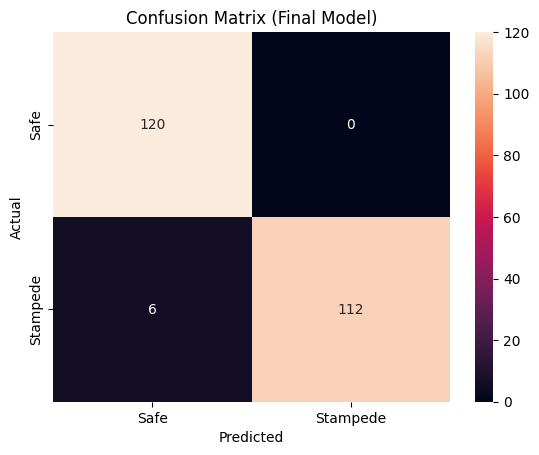

In [29]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# correct predictions
y_prob = best_kfold_model.predict(X_test)
y_pred = (y_prob > best_threshold).astype(int).ravel()
y_true = y_test.ravel()

# metrics
cm = confusion_matrix(y_true, y_pred)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

# heatmap
plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Safe','Stampede'],
            yticklabels=['Safe','Stampede'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Final Model)")
plt.show()

In [30]:
# from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
# import seaborn as sns
# import matplotlib.pyplot as plt
# %matplotlib inline

# cm = confusion_matrix(y_test, y_pred)

# acc = accuracy_score(y_test, y_pred)
# prec = precision_score(y_test, y_pred)
# rec = recall_score(y_test, y_pred)
# f1 = f1_score(y_test, y_pred)

# print("Accuracy:", acc)
# print("Precision:", prec)
# print("Recall:", rec)
# print("F1 Score:", f1)

# y_pred = (y_pred > 0.5).astype(int).ravel()
# y_test = y_test.ravel()
# from sklearn.metrics import confusion_matrix

# cm = confusion_matrix(y_test, y_pred)

# print(cm)

# plt.figure()
# sns.heatmap(cm, annot=True, fmt='d',
#             xticklabels=['Safe','Stampede'],
#             yticklabels=['Safe','Stampede'])
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix")
# plt.show()

## 11. Save Models

In [31]:

mcnn.save("mcnn_model.h5")
print("Saved: mcnn_model.h5")


if best_kfold_model is not None:
    best_kfold_model.save("mcnn_best_kfold.h5")
    print("Saved: mcnn_best_kfold.h5")

Saved: mcnn_model.h5
Saved: mcnn_best_kfold.h5


## 12. Final Comparison Table

In [32]:
print("\n" + "=" * 60)
print("FINAL COMPARISON TABLE")
print("=" * 60)
print(f"\n{'Model':<35} {'Test AUC':>10}")
print("-" * 47)
for model_name, auc_val in results_summary.items():
    print(f"{model_name:<35} {auc_val:>10.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(max(6, len(results_summary) * 3), 5))
models = list(results_summary.keys())
aucs   = list(results_summary.values())
x      = np.arange(len(models))
bars   = ax.bar(x, aucs, 0.5, color='steelblue', alpha=0.8)

for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01, f'{val:.4f}',
            ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.set_ylabel('AUC')
ax.set_title('Model Comparison – AUC')
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='Random baseline')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'model_comparison.png'), dpi=150)
plt.close()

print(f"\nAll outputs saved in → {OUTPUT_DIR}")
print("Done! ✓")


FINAL COMPARISON TABLE

Model                                 Test AUC
-----------------------------------------------
MCNN v4                                 0.9983
Improved MCNN (K-Fold AUC)              0.9945

All outputs saved in → output_plots/
Done! ✓


In [33]:
#from google.colab import drive
#drive.mount('/content/drive')

## 13. Test on New Images

In [34]:
from google.colab import files
uploaded = files.upload()

Saving test_images.zip to test_images.zip


In [35]:
import zipfile

with zipfile.ZipFile('test_images.zip', 'r') as zip_ref:
    zip_ref.extractall()

print(os.listdir('test_images'))

['test img2.jpg', 'test img5.jpg', 'test img4.jpg', 'test img1.jpg', 'test img6.jpg', 'test img3.jpg']


Using calibrated threshold: 0.477

Image: test img2.jpg
  Probability : 1.000
  Prediction  : Stampede
  Risk Level  : High Risk


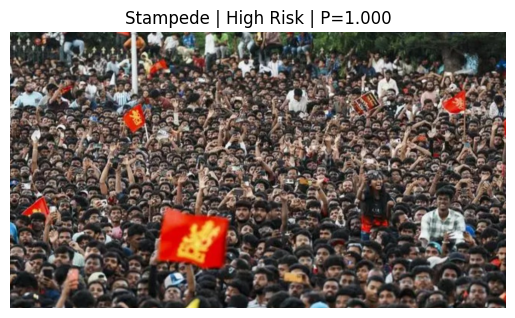


Image: test img5.jpg
  Probability : 0.872
  Prediction  : Stampede
  Risk Level  : High Risk


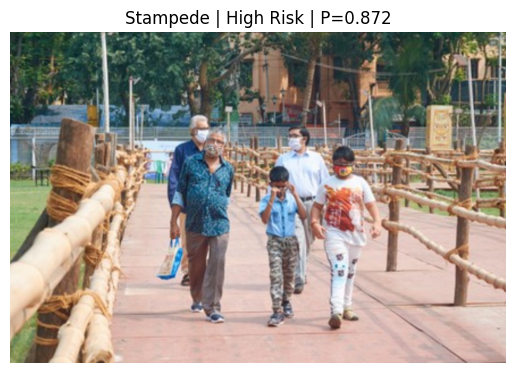


Image: test img4.jpg
  Probability : 0.245
  Prediction  : Safe
  Risk Level  : Low Risk


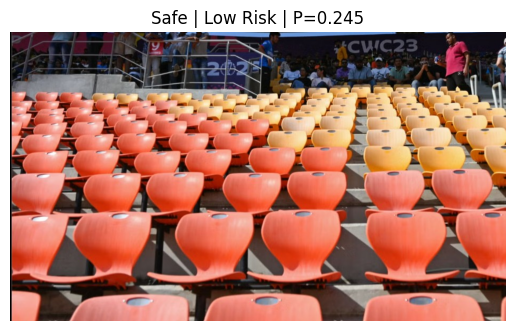


Image: test img1.jpg
  Probability : 1.000
  Prediction  : Stampede
  Risk Level  : High Risk


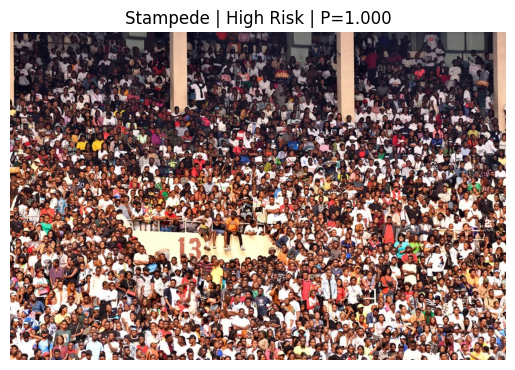


Image: test img6.jpg
  Probability : 0.000
  Prediction  : Safe
  Risk Level  : Low Risk


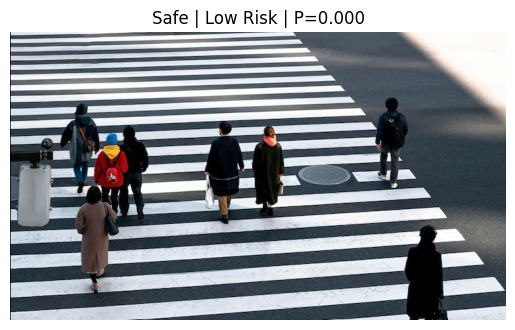


Image: test img3.jpg
  Probability : 1.000
  Prediction  : Stampede
  Risk Level  : High Risk


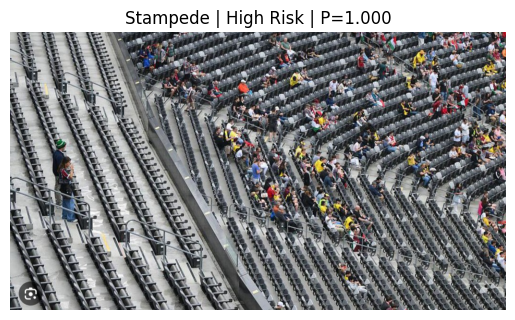

In [36]:
def get_risk_level(prob, threshold):
    """Three-tier risk level based on distance from the calibrated threshold."""
    if prob < threshold * 0.7:
        return "Low Risk"
    elif prob < threshold * 1.5:
        return "Medium Risk"
    return "High Risk"


print(f"Using calibrated threshold: {best_threshold:.3f}")


folder = "test_images"

for file in os.listdir(folder):
    if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
        continue

    path = os.path.join(folder, file)
    img  = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Skipping:", file)
        continue

    img_input = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype('float32') / 255.0
    img_input = np.expand_dims(img_input, axis=(0, -1))

    prob = mcnn.predict(img_input, verbose=0)[0][0]
    pred = "Stampede" if prob >= best_threshold else "Safe"
    risk = get_risk_level(prob, best_threshold)

    print(f"\nImage: {file}")
    print(f"  Probability : {prob:.3f}")
    print(f"  Prediction  : {pred}")
    print(f"  Risk Level  : {risk}")

    img_color = cv2.imread(path)
    plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
    plt.title(f"{pred} | {risk} | P={prob:.3f}")
    plt.axis('off')
    plt.show()